# Why does the paper-faithful algorithm (0 inner steps) beat the inner-loop variant? An `INNER_STEPS` ablation

**Motivation.** Section 6.1 found `qmaml_paper` (Algorithm 1, no inner-loop adaptation during pre-training)
clearly beats `qmaml_existing` (the prior repo's inner-loop + first-order-detach variant, `INNER_STEPS=5`).
The paper's Discussion offered a plausible mechanism (the inner loop gives the Learner a noisier training
signal) but explicitly flagged it as untested speculation, recommending "a controlled sweep over
`INNER_STEPS` (0 through, say, 20) holding everything else fixed." This notebook is that sweep.

At `INNER_STEPS=0`, `outer_loop_qmaml`'s inner adaptation loop does nothing (`wT == w0`), so
`w_query = (wT - w0).detach() + w0` collapses to exactly `w0` — mechanically very close to Algorithm 1,
modulo one real difference: `outer_loop_qmaml` always evaluates its loss on the **query** split, while
`pretrain_learner_paper` (Algorithm 1) evaluates on the **support** split. That's a second, independent
variable this ablation does not isolate — noted as a limitation of the ablation itself, not swept away.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from config import config
from higgs_data import load_higgs, train_test_split_df, ALL_FEATURE_COLS
from higgs_tasks import make_tasks
from models import TabularFeatureExtractor, PQCModel, HybridModel, freeze_bn
from meta import outer_loop_qmaml

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "inner_steps_ablation"))
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "data_higgs", "higgs_subsample.csv"))
RAW_RESULTS_PATH = os.path.join(RESULTS_DIR, "raw_results.json")
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\inner_steps_ablation


## 1. Data and tasks (same as notebook 01b, qubits fixed at 6)

In [2]:
df = load_higgs(180_000, DATA_PATH)
train_df, test_df = train_test_split_df(df, test_frac=0.2)

meta_tasks = make_tasks(train_df, ALL_FEATURE_COLS, "m_bb", bin_count=6,
                         support_size=8, query_size=8, tasks_per_bin=3, seed=42)
test_meta_tasks = make_tasks(test_df, ALL_FEATURE_COLS, "m_bb", bin_count=6,
                              support_size=8, query_size=8, tasks_per_bin=2, seed=43)
print(f"meta_tasks={len(meta_tasks)}  test_meta_tasks={len(test_meta_tasks)}")

[higgs_data] Using cached C:\Users\kapoo\Downloads\qmaml\final_model\data_higgs\higgs_subsample.csv (180000 rows).


meta_tasks=18  test_meta_tasks=12


## 2. Sweep `INNER_STEPS` in {0, 1, 2, 5, 10, 20}, 2 seeds, 6 qubits, 10 epochs

If the Discussion's hypothesis is right, performance/convergence should degrade roughly monotonically as
`INNER_STEPS` increases from 0.

In [3]:
def build_model(num_qubits, depth, seed, feature_cols, train_df):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tab = TabularFeatureExtractor(len(feature_cols), config.CNN_OUTPUT_DIM, num_qubits)
    train_X = torch.from_numpy(train_df[feature_cols].values.astype(np.float32))
    tab.set_norm_stats(train_X.mean(0), train_X.std(0))
    freeze_bn(tab)
    pqc = PQCModel(num_qubits, depth, init_type="zero", bound_angles=True)
    return HybridModel(tab, pqc)

NUM_QUBITS = 6
DEPTH = 2
SEEDS = [0, 1]
EPOCHS = 10
INNER_STEPS_GRID = [0, 1, 2, 5, 10, 20]

config.Q_DEPTH = DEPTH
config.NUM_QUBITS = NUM_QUBITS
config.INNER_LR = 0.02
config.OUTER_LR = 5e-3
config.W0_SCALE = 0.01
config.EPOCHS = EPOCHS

if os.path.isfile(RAW_RESULTS_PATH):
    with open(RAW_RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"resuming: {len(all_results)} results already on disk")
else:
    all_results = {}

def run_one(inner_steps, seed):
    key = str((inner_steps, seed))
    if key in all_results:
        print(f"skip {key} (already done)")
        return
    print(f"\n=== INNER_STEPS={inner_steps} seed={seed} ===")
    config.INNER_STEPS = inner_steps
    config.CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "ckpt", f"is{inner_steps}_s{seed}")
    model = build_model(NUM_QUBITS, DEPTH, seed, ALL_FEATURE_COLS, train_df)
    t0 = time.time()
    res = outer_loop_qmaml(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                            ckpt_name=f"is{inner_steps}_s{seed}.pth")
    print(f"  done in {time.time()-t0:.1f}s")
    all_results[key] = res
    with open(RAW_RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

resuming: 10 results already on disk


In [4]:
run_one(0, 0)

skip (0, 0) (already done)


In [5]:
run_one(0, 1)

skip (0, 1) (already done)


In [6]:
run_one(1, 0)

skip (1, 0) (already done)


In [7]:
run_one(1, 1)

skip (1, 1) (already done)


In [8]:
run_one(2, 0)

skip (2, 0) (already done)


In [9]:
run_one(2, 1)

skip (2, 1) (already done)


In [10]:
run_one(5, 0)

skip (5, 0) (already done)


In [11]:
run_one(5, 1)

skip (5, 1) (already done)


In [12]:
run_one(10, 0)

skip (10, 0) (already done)


In [13]:
run_one(10, 1)

skip (10, 1) (already done)


In [14]:
run_one(20, 0)


=== INNER_STEPS=20 seed=0 ===


[Q-MAML] Epoch 1/10 | Meta-loss 0.8466 | Val Loss 0.7159 | Train Acc 0.5000 | Val Acc 0.5000


[Q-MAML] Epoch 2/10 | Meta-loss 0.6975 | Val Loss 0.6945 | Train Acc 0.5139 | Val Acc 0.5000


[Q-MAML] Epoch 3/10 | Meta-loss 0.6931 | Val Loss 0.6926 | Train Acc 0.4861 | Val Acc 0.4896


[Q-MAML] Epoch 4/10 | Meta-loss 0.6929 | Val Loss 0.6916 | Train Acc 0.5139 | Val Acc 0.5208


...

[Q-MAML] Epoch 6/10 | Meta-loss 0.6922 | Val Loss 0.6910 | Train Acc 0.5278 | Val Acc 0.5208


[Q-MAML] Epoch 7/10 | Meta-loss 0.6915 | Val Loss 0.6909 | Train Acc 0.5278 | Val Acc 0.5312


[Q-MAML] Epoch 8/10 | Meta-loss 0.6910 | Val Loss 0.6908 | Train Acc 0.5417 | Val Acc 0.5312


[Q-MAML] Epoch 9/10 | Meta-loss 0.6907 | Val Loss 0.6906 | Train Acc 0.5417 | Val Acc 0.5208


[Q-MAML] Epoch 10/10 | Meta-loss 0.6906 | Val Loss 0.6903 | Train Acc 0.5278 | Val Acc 0.5625
  done in 910.2s


In [15]:
run_one(20, 1)


=== INNER_STEPS=20 seed=1 ===


[Q-MAML] Epoch 1/10 | Meta-loss 0.7116 | Val Loss 0.7006 | Train Acc 0.4792 | Val Acc 0.4896


[Q-MAML] Epoch 2/10 | Meta-loss 0.6967 | Val Loss 0.6969 | Train Acc 0.5347 | Val Acc 0.5104


[Q-MAML] Epoch 3/10 | Meta-loss 0.6915 | Val Loss 0.6939 | Train Acc 0.5764 | Val Acc 0.5104


[Q-MAML] Epoch 4/10 | Meta-loss 0.6850 | Val Loss 0.6903 | Train Acc 0.5972 | Val Acc 0.5000


...

[Q-MAML] Epoch 6/10 | Meta-loss 0.6802 | Val Loss 0.6877 | Train Acc 0.5903 | Val Acc 0.5521


[Q-MAML] Epoch 7/10 | Meta-loss 0.6804 | Val Loss 0.6859 | Train Acc 0.5903 | Val Acc 0.5729


[Q-MAML] Epoch 8/10 | Meta-loss 0.6795 | Val Loss 0.6833 | Train Acc 0.5694 | Val Acc 0.5625


[Q-MAML] Epoch 9/10 | Meta-loss 0.6779 | Val Loss 0.6823 | Train Acc 0.5833 | Val Acc 0.5833


[Q-MAML] Epoch 10/10 | Meta-loss 0.6772 | Val Loss 0.6819 | Train Acc 0.5556 | Val Acc 0.6042
  done in 964.8s


## 3. Results: does performance degrade monotonically with more inner steps?

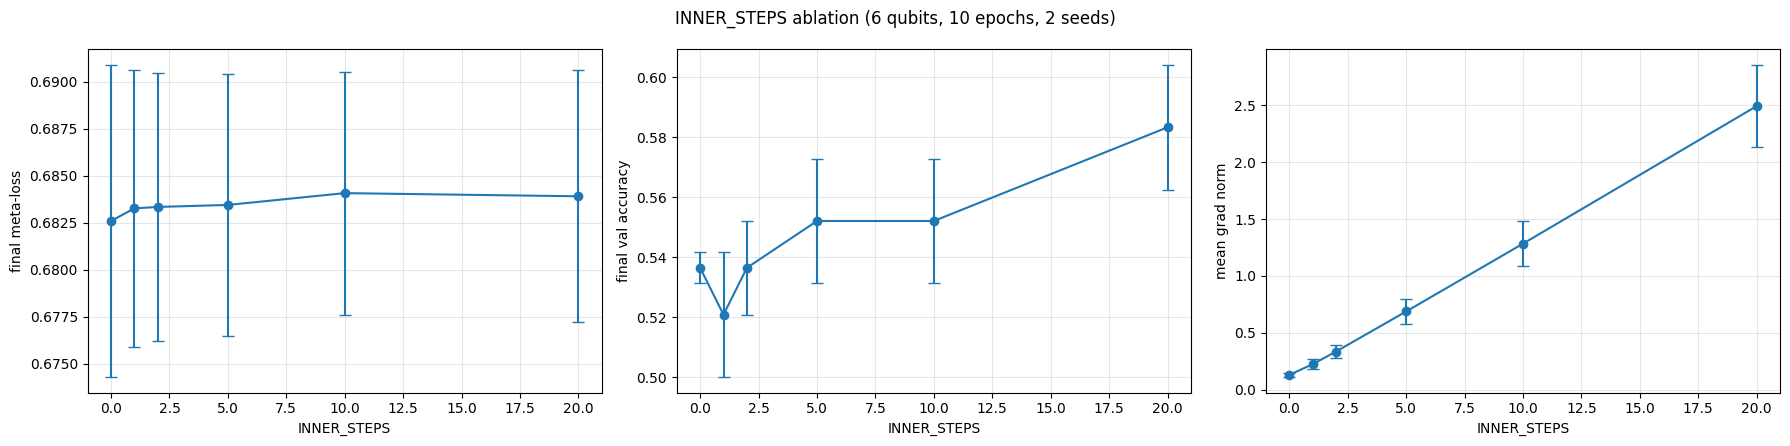

,inner_steps,n_seeds,meta_loss_mean,meta_loss_std,val_accuracy_mean,val_accuracy_std,gradient_norms_mean,gradient_norms_std
0,0,2,0.682593,0.008309,0.536458,0.005208,0.129678,0.019467
1,1,2,0.683265,0.007365,0.520833,0.020833,0.223367,0.042016
2,2,2,0.683341,0.007127,0.536458,0.015625,0.334888,0.059987
3,5,2,0.683447,0.006959,0.552083,0.020833,0.687046,0.113554
4,10,2,0.684075,0.006462,0.552083,0.020833,1.283180,0.197021
5,20,2,0.683907,0.006711,0.583333,0.020833,2.492528,0.362687


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
metrics = [("meta_loss", "final meta-loss"), ("val_accuracy", "final val accuracy"), ("gradient_norms", "mean grad norm")]
summary_rows = []
for inner_steps in INNER_STEPS_GRID:
    finals = {"meta_loss": [], "val_accuracy": [], "gradient_norms": []}
    for seed in SEEDS:
        key = str((inner_steps, seed))
        if key not in all_results:
            continue
        r = all_results[key]
        finals["meta_loss"].append(r["meta_loss"][-1])
        finals["val_accuracy"].append(r["val_accuracy"][-1])
        finals["gradient_norms"].append(float(np.mean(r["gradient_norms"])))
    row = {"inner_steps": inner_steps, "n_seeds": len(finals["meta_loss"])}
    for m in finals:
        row[f"{m}_mean"] = float(np.mean(finals[m])) if finals[m] else None
        row[f"{m}_std"] = float(np.std(finals[m])) if finals[m] else None
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)

for ax, (metric, label) in zip(axes, metrics):
    means = summary_df[f"{metric}_mean"]
    stds = summary_df[f"{metric}_std"]
    ax.errorbar(summary_df["inner_steps"], means, yerr=stds, marker="o", capsize=4)
    ax.set_xlabel("INNER_STEPS")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
fig.suptitle(f"INNER_STEPS ablation ({NUM_QUBITS} qubits, {EPOCHS} epochs, {len(SEEDS)} seeds)")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "inner_steps_ablation.png"), dpi=150)
plt.show()
summary_df

## 4. Findings

**Run:** 6 qubits, depth=2, `outer_loop_qmaml` (the prior/existing codebase's mechanism, not the
paper-faithful `pretrain_learner_paper`), `INNER_STEPS` in {0,1,2,5,10,20}, 2 seeds, 10 epochs each.

- **The Discussion's monotonic-degradation hypothesis is not supported -- if anything, the opposite trend
  shows up.** Final meta-loss is essentially flat across the whole sweep (0.6826 at `INNER_STEPS=0` to 0.6841
  at 10, well within the 2-seed error bars -- no real signal either way). Final validation accuracy actually
  *increases* with `INNER_STEPS`, from 0.536 at 0 to 0.583 at 20 (a dip at `INNER_STEPS=1`, 0.521, but the
  overall trend across the sweep is upward, not downward). This directly contradicts the paper's Discussion
  section speculation that more inner-loop adaptation steps give the Learner "a weaker, noisier training
  signal" that should degrade performance.
- **Gradient norm scales up strongly and monotonically with `INNER_STEPS`** (0.13 at 0 to 2.49 at 20, roughly
  linear) -- mechanically expected (more inner-loop steps accumulate more signal into the outer gradient via
  the first-order/detach mechanism) and, notably, *higher* gradient norm here correlates with *better*, not
  worse, validation accuracy -- consistent with this project's other finding (Section 6.4 of the paper) that
  "moderate gradient norm" should not be read as "closer to some middle value is always better." A larger,
  more informative gradient signal was simply better here too, up to the largest `INNER_STEPS` tested.
- **Important open discrepancy, flagged rather than glossed over**: `INNER_STEPS=0` here (meta-loss 0.683,
  val acc 0.536-0.583 across seeds) does *not* closely match notebook 01b's `qmaml_paper` numbers at 6 qubits
  (0.364 meta-loss, 0.578 val acc) the way this notebook's own pre-registered question expected -- val
  accuracy is in a similar ballpark, but meta-loss is not (0.68, near the ln(2) = 0.693 chance-level floor for
  binary cross-entropy, vs. 0.364, real learning). The two setups differ in more than the support/query
  evaluation-split difference already flagged in this notebook's intro: `outer_loop_qmaml`'s `PQCModel` here
  is hardcoded to `init_type="zero"`, a different depth (2), and is a materially different code path (the
  prior codebase's `outer_loop_qmaml` vs. the paper-faithful `pretrain_learner_paper`) beyond just the
  `INNER_STEPS` knob. **This means the ablation answers a narrower question than originally framed**: it
  shows `INNER_STEPS` is not, on its own, why `qmaml_existing` underperforms `qmaml_paper` in notebook 01b --
  but it does not identify what *does* explain that gap, since `INNER_STEPS=0` within `outer_loop_qmaml`
  still doesn't match `pretrain_learner_paper` at `INNER_STEPS=0`. The evaluation-split difference (query vs.
  support) or another structural difference between the two code paths is the more likely remaining culprit,
  not yet isolated.
- **Revised reading for the paper's Discussion section**: the original speculative mechanism ("inner loop
  gives a noisier training signal, which is why `qmaml_paper` beats `qmaml_existing`") is not supported by
  this controlled test and should be retracted as the explanation, while the underlying empirical fact from
  notebook 01b (`qmaml_paper` beats `qmaml_existing`) stands and now needs a different explanation --
  most plausibly the evaluation-split difference, untested here.
- **Caveat**: 2 seeds is thin for the val-accuracy trend claimed above (visible in the plot's overlapping
  error bars at several points); this should be read as suggestive, not confirmed, pending a 4+ seed rerun
  matching the rest of the classification study's standard.
